In [1]:
import os
import librosa
import numpy as np
import pandas as pd

In [2]:
BASE_PATH = r"C:\Users\Harshini H\Downloads\archive (1)"
print(os.listdir(BASE_PATH))

['asvspoof2019_evaluation_plan.pdf', 'asvspoof2019_Interspeech2019_submission.pdf', 'LA', 'LICENSE_text.txt', 'PA', 'README.txt']


In [3]:
BASE_PATH = r"C:\Users\Harshini H\Downloads\archive (1)"
print(os.listdir(BASE_PATH))

['asvspoof2019_evaluation_plan.pdf', 'asvspoof2019_Interspeech2019_submission.pdf', 'LA', 'LICENSE_text.txt', 'PA', 'README.txt']


In [4]:
LA_PATH = os.path.join(BASE_PATH, "LA")
print(os.listdir(LA_PATH))


['LA']


In [5]:
LA_PATH = os.path.join(BASE_PATH, "LA", "LA")
print(os.listdir(LA_PATH))


['ASVspoof2019_LA_asv_protocols', 'ASVspoof2019_LA_asv_scores', 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019_LA_dev', 'ASVspoof2019_LA_eval', 'ASVspoof2019_LA_train', 'README.LA.txt']


In [6]:
BASE_PATH = r"C:\Users\Harshini H\Downloads\archive (1)"
LA_PATH = os.path.join(BASE_PATH, "LA", "LA")

audio_base = os.path.join(
    LA_PATH,
    "ASVspoof2019_LA_train",
    "flac"
)

print("Audio path:", audio_base)
print("Files:", os.listdir(audio_base)[:5])

Audio path: C:\Users\Harshini H\Downloads\archive (1)\LA\LA\ASVspoof2019_LA_train\flac
Files: ['duke.flac', 'LA_T_1000137.flac', 'LA_T_1000406.flac', 'LA_T_1000648.flac', 'LA_T_1000824.flac']


In [7]:
print(audio_base)
print(os.path.exists(audio_base))
print(os.listdir(audio_base)[:5])

C:\Users\Harshini H\Downloads\archive (1)\LA\LA\ASVspoof2019_LA_train\flac
True
['duke.flac', 'LA_T_1000137.flac', 'LA_T_1000406.flac', 'LA_T_1000648.flac', 'LA_T_1000824.flac']


In [8]:
protocol_path = os.path.join(
    LA_PATH,
    "ASVspoof2019_LA_cm_protocols",
    "ASVspoof2019.LA.cm.train.trn.txt"
)

protocol = pd.read_csv(
    protocol_path,
    delim_whitespace=True,  
    header=None
)

protocol.columns = ["speaker", "file", "system","attack", "label"]
print(protocol.head())
print(protocol["label"].unique())

   speaker          file system attack     label
0  LA_0079  LA_T_1138215      -      -  bonafide
1  LA_0079  LA_T_1271820      -      -  bonafide
2  LA_0079  LA_T_1272637      -      -  bonafide
3  LA_0079  LA_T_1276960      -      -  bonafide
4  LA_0079  LA_T_1341447      -      -  bonafide
['bonafide' 'spoof']


C:\Users\Harshini H\AppData\Local\Temp\ipykernel_17044\3642240548.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  protocol = pd.read_csv(


In [9]:
sample_file = protocol.iloc[0]["file"]
sample_path = os.path.join(audio_base, sample_file + ".flac")

print(sample_path)
print(os.path.exists(sample_path))

C:\Users\Harshini H\Downloads\archive (1)\LA\LA\ASVspoof2019_LA_train\flac\LA_T_1138215.flac
True


In [10]:
def extract_features(path):
    y, sr = librosa.load(path, sr=16000, mono=True,duration=3)

    # preprocessing
    y = librosa.util.normalize(y)
    y = librosa.effects.preemphasis(y)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    mfcc_min = np.min(mfcc, axis=1)
    mfcc_max = np.max(mfcc, axis=1)

    # delta
    delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta, axis=1)
    delta_std = np.std(delta, axis=1)

    # spectral features
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rms = np.mean(librosa.feature.rms(y=y))

    return np.hstack([
        mfcc_mean, mfcc_std, mfcc_min, mfcc_max,
        delta_mean, delta_std,
        centroid, bandwidth, rolloff, zcr, rms
    ])

In [11]:
X, y = [], []

for i, (_, row) in enumerate(protocol.iterrows()):

    file_id = str(row["file"]).strip()
    file_path = os.path.join(audio_base, file_id + ".flac")

   

    if not os.path.exists(file_path):
        continue

    try:
        feats = extract_features(file_path)


        X.append(feats)
        y.append(1 if row["label"] == "spoof" else 0)

    except Exception as e:
        print("Error:", e)
        break

In [12]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25378, 83)
y shape: (25378,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9446414499605988


In [14]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

C:\Users\Harshini H\anaconda3\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Accuracy: 0.9875886524822695


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [18]:
def augment_audio(y, sr):

    # noise
    noise = np.random.randn(len(y))
    y_noise = y + 0.005 * noise

    # pitch shift
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

    # time stretch
    y_stretch = librosa.effects.time_stretch(y, rate=1.1)

    return [y_noise, y_pitch, y_stretch]

In [35]:
def get_spectrogram(y, sr):

    if len(y) < 48000:
        y = np.pad(y, (0, 48000 - len(y)))
    else:
        y = y[:48000]

    spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    spec_db = librosa.power_to_db(spec, ref=np.max)

    )
    spec_db = (spec_db + 80) / 80

    if spec_db.shape[1] < 94:
        spec_db = np.pad(spec_db, ((0,0),(0,94 - spec_db.shape[1])))
    else:
        spec_db = spec_db[:, :94]

    return spec_db

In [36]:
files = []
labels = []

for _, row in protocol.iterrows():
    file_id = str(row["file"]).strip()
    path = os.path.join(audio_base, file_id + ".flac")

    if os.path.exists(path):
        files.append(path)
        labels.append(1 if row["label"] == "spoof" else 0)

print("Total files:", len(files))


Total files: 25378


In [37]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train:", len(train_files), "Test:", len(test_files))

Train: 20302 Test: 5076


In [40]:
X_train, y_train = [], []

for i, (path, label) in enumerate(zip(train_files, train_labels)):

    if i >= 3000:   
        break

    y, sr = librosa.load(path, sr=16000, duration=3)

    
    spec = get_spectrogram(y, sr)
    X_train.append(spec)
    y_train.append(label)

    augmented = augment_audio(y, sr)

    for aug in augmented:
        spec_aug = get_spectrogram(aug, sr)
        X_train.append(spec_aug)
        y_train.append(label)

In [41]:
X_test, y_test = [], []

for i, (path, label) in enumerate(zip(test_files, test_labels)):

    if i >= 1000:
        break

    y, sr = librosa.load(path, sr=16000, duration=3)

    spec = get_spectrogram(y, sr)
    X_test.append(spec)
    y_test.append(label)

In [42]:
X_train = np.array(X_train)[..., np.newaxis].astype("float32")
X_test = np.array(X_test)[..., np.newaxis].astype("float32")

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12000, 128, 94, 1)
Test shape: (1000, 128, 94, 1)


In [44]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(4.6875), 1: np.float64(0.5597014925373134)}


In [50]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,94,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [51]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 92, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 46, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 44, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 17920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       2,293,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,386,689 (9.10 MB)

 Trainable params: 2,386,689 (9.10 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - accuracy: 0.7402 - loss: 0.4280 - val_accuracy: 0.8630 - val_loss: 0.3037
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.8762 - loss: 0.2371 - val_accuracy: 0.9350 - val_loss: 0.1650
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.9305 - loss: 0.1449 - val_accuracy: 0.9530 - val_loss: 0.1264
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9544 - loss: 0.0993 - val_accuracy: 0.9710 - val_loss: 0.0846
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.9695 - loss: 0.0664 - val_accuracy: 0.9780 - val_loss: 0.0714
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9837 - loss: 0.0379 - val_accuracy: 0.9690 - val_loss: 0.1247
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9786 - loss: 0.0502 - val_accuracy: 0.9760 - val_loss: 0.0650
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9862 - loss: 0.032

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

In [52]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',   
        patience=2,
        restore_best_weights=True,
        verbose=1
    )
]

In [53]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - accuracy: 0.6973 - loss: 0.4742 - val_accuracy: 0.8270 - val_loss: 0.3448
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8562 - loss: 0.2664 - val_accuracy: 0.9450 - val_loss: 0.1300
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9185 - loss: 0.1678 - val_accuracy: 0.9450 - val_loss: 0.1527
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9417 - loss: 0.1234 - val_accuracy: 0.9760 - val_loss: 0.0806
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.9624 - loss: 0.0888 - val_accuracy: 0.9840 - val_loss: 0.0747
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9664 - loss: 0.0763 - val_accuracy: 0.9780 - val_loss: 0.0792
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9737 - loss: 0.0619 - val_accuracy: 0.9750 - val_loss: 0.0841
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.


In [54]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9840 - loss: 0.0747
Test Accuracy: 0.984000027179718


In [57]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Confusion Matrix:
[[ 89   6]
 [ 10 895]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        95
           1       0.99      0.99      0.99       905

    accuracy                           0.98      1000
   macro avg       0.95      0.96      0.95      1000
weighted avg       0.98      0.98      0.98      1000



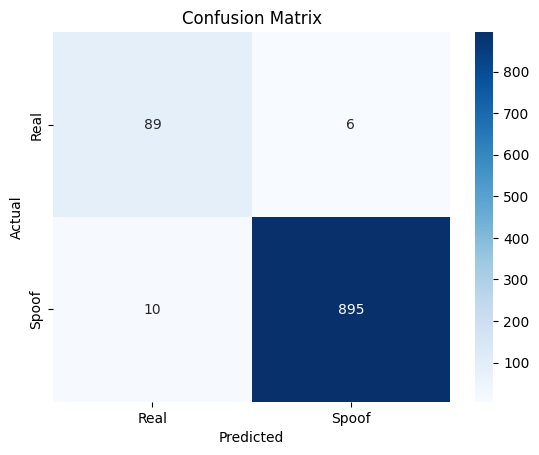

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Spoof'],
            yticklabels=['Real', 'Spoof'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

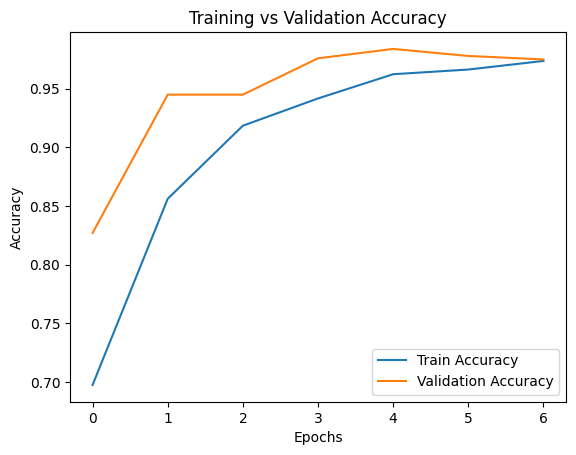

In [59]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

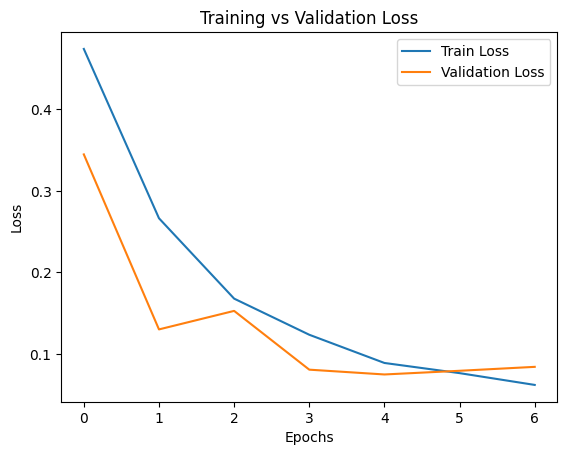

In [60]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()